<a href="https://colab.research.google.com/github/ashwithareddykatta-code/sentiment-analysis-projects/blob/main/task_7_LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy nltk scikit-learn gensim matplotlib seaborn

OVERALL IDEA (What this code does)

You had:
👉 3000 customer reviews (text data)

Goal:
👉 Convert text → find hidden topics → understand why customers are unhappy

This is done using Latent Dirichlet Allocation (LDA)

In [ ]:
import pandas as pd
import numpy as np
import nltk
import re

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/yelp.csv"
df = pd.read_csv(url)

df = df.sample(3000, random_state=42)
reviews = df['text']

print("Total Reviews:", len(reviews))

Total Reviews: 3000


In [ ]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)   # remove numbers & symbols
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

cleaned_reviews = reviews.apply(clean_text)

cleaned_reviews.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text
6252,got around midnight last friday place dead how...
4684,brought friend louisiana says crawfish etouffe...
1731,every friday dad eat order thing pizza wraps g...
4742,husband really really disappointed experience ...
4521,love place phoenix weeks work ate times squid ...


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_df=0.9, min_df=10)
X = vectorizer.fit_transform(cleaned_reviews)

print("Shape of matrix:", X.shape)

Shape of matrix: (3000, 2455)


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

In [ ]:
words = vectorizer.get_feature_names_out()

def display_topics(model, words, no_top_words):
    for i, topic in enumerate(model.components_):
        print(f"\n🔹 Topic {i+1}:")
        print(", ".join([words[i] for i in topic.argsort()[-no_top_words:]]))

display_topics(lda, words, 10)


🔹 Topic 1:
really, also, time, great, good, go, get, one, place, like

🔹 Topic 2:
best, love, mexican, fries, like, burger, great, place, good, food

🔹 Topic 3:
really, salad, chicken, ordered, go, great, like, place, food, good

🔹 Topic 4:
place, like, service, would, one, order, back, time, get, pizza

🔹 Topic 5:
night, sushi, nice, bar, us, service, good, great, food, place


In [ ]:
topic_values = lda.transform(X)

df['Dominant_Topic'] = topic_values.argmax(axis=1)

df[['text', 'Dominant_Topic']].head()

,text,Dominant_Topic
6252,We got here around midnight last Friday... the...,4
4684,Brought a friend from Louisiana here. She say...,3
1731,"Every friday, my dad and I eat here. We order ...",4
4742,"My husband and I were really, really disappoin...",3
4521,Love this place! Was in phoenix 3 weeks for w...,1


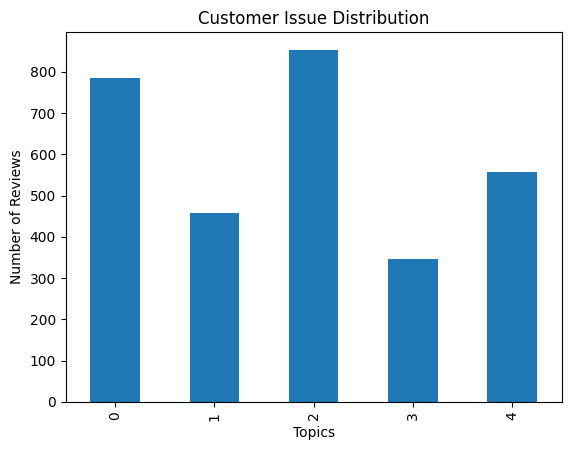

In [ ]:
import matplotlib.pyplot as plt

topic_counts = df['Dominant_Topic'].value_counts().sort_index()

plt.figure()
topic_counts.plot(kind='bar')
plt.title("Customer Issue Distribution")
plt.xlabel("Topics")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
print(type(vectorizer))
print(type(lda))

<class 'sklearn.feature_extraction.text.CountVectorizer'>
<class 'sklearn.decomposition._lda.LatentDirichletAllocation'>


frontend

In [ ]:
!pip install ipywidgets

In [ ]:
import ipywidgets as widgets
from IPython.display import display

In [ ]:
# Text input box
review_input = widgets.Textarea(
    value='',
    placeholder='Enter customer review here...',
    description='Review:',
    layout=widgets.Layout(width='500px', height='100px')
)

# Button
analyze_button = widgets.Button(
    description="Analyze Review",
    button_style='success'
)

# Output area
output = widgets.Output()

display(review_input, analyze_button, output)

Textarea(value='', description='Review:', layout=Layout(height='100px', width='500px'), placeholder='Enter cus…

Button(button_style='success', description='Analyze Review', style=ButtonStyle())

Output()

# New section